# Machine Learning 지도학습 - 분류


## ⚙️환경설정


In [1]:
# scikit-learn 설치
!pip install scikit-learn

In [2]:
import sklearn
sklearn.__version__

'1.9.0'

In [3]:
# 라이브러리와 한글 폰트 설정
from pathlib import Path
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

# 운영체제별 한글 폰트 후보
font_candidates = {
    "Darwin": ["AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Windows": ["Malgun Gothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
    "Linux": ["NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"],
}

available_fonts = {font.name for font in fm.fontManager.ttflist}
selected_font = None

for font_name in font_candidates.get(platform.system(), []):
    if font_name in available_fonts:
        selected_font = font_name
        break

if selected_font:
    plt.rcParams["font.family"] = selected_font
    print("설정된 한글 폰트:", selected_font)
else:
    print("사용 가능한 한글 폰트를 찾지 못했습니다. 그래프의 한글이 깨질 수 있습니다.")

# 마이너스 기호 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid", rc={"axes.unicode_minus": False})
if selected_font:
    sns.set_theme(style="whitegrid", rc={"font.family": selected_font, "axes.unicode_minus": False})

설정된 한글 폰트: Malgun Gothic


## 생선 이진 분류 - 도미냐? 빙어냐?
<table>
    <tr>
        <td><img src="https://d.pr/i/FaQ4RH+" width="300"></td>
        <td><img src="https://d.pr/i/NmXwPX+" width="300"></td>
    </tr>
</table>


In [9]:
# 도미와 빙어의 길이/무게 원자료

# 도미 bream 데이터 35개
# bream_length: 도미 35마리의 길이
# bream_weight: 도미 35마리의 무게
bream_length = [25.4, 26.3, 26.5, 29.0, 29.0, 29.7, 29.7, 30.0, 30.0, 30.7, 31.0, 31.0, 31.5, 32.0, 32.0, 32.0, 33.0, 33.0, 33.5, 33.5, 34.0, 34.0, 34.5, 35.0, 35.0, 35.0, 35.0, 36.0, 36.0, 37.0, 38.5, 38.5, 39.5, 41.0, 41.0]
bream_weight = [242.0, 290.0, 340.0, 363.0, 430.0, 450.0, 500.0, 390.0, 450.0, 500.0, 475.0, 500.0, 500.0, 340.0, 600.0, 600.0, 700.0, 700.0, 610.0, 650.0, 575.0, 685.0, 620.0, 680.0, 700.0, 725.0, 720.0, 714.0, 850.0, 1000.0, 920.0, 955.0, 925.0, 975.0, 950.0]

# 빙어 smelt 데이터 14개
# smelt_length: 빙어 14마리의 길이
# smelt_weight: 빙어 14마리의 무게
smelt_length = [9.8, 10.5, 10.6, 11.0, 11.2, 11.3, 11.8, 11.8, 12.0, 12.2, 12.4, 13.0, 14.3, 15.0]
smelt_weight = [6.7, 7.5, 7.0, 9.7, 9.8, 8.7, 10.0, 9.9, 9.8, 12.2, 13.4, 12.2, 19.7, 19.9]

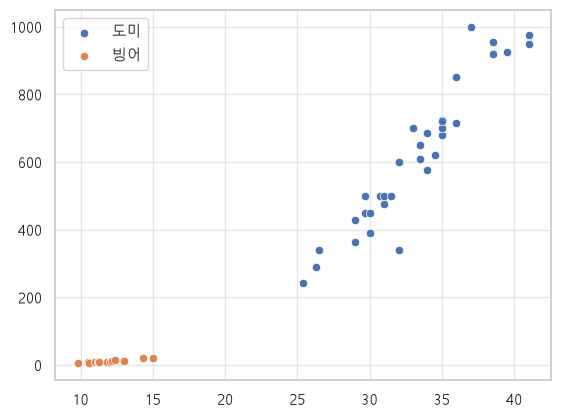

In [11]:
# 산점도표를 이용해서 도미와 빙어의 분포를 확인
sns.scatterplot(
    x = bream_length,
    y = bream_weight,
    label = '도미'
)

sns.scatterplot(
    x = smelt_length,
    y = smelt_weight,
    label = '빙어'
)

plt.legend()
plt.show()

## KNN K-최근접이웃분류모델
데이터포인트간의 거리기반으로 분류를 수행하는 모델


### k-최근접 이웃 알고리즘 작동원리

최근접이웃(K-Nearest Neighbors, KNN)에서 거리를 구하는 방법으로 가장 일반적으로 사용되는 방법은 **유클리드 거리(Euclidean distance)**이다.

유클리드 거리란 "두 점 사이의 직선 거리" 를 구하는 가장 간단한 방법이다.

좌표상 (0, 0)과 (3, 4)라는 점 두 개를 찍었다고 하자. 이 두 점을 선으로 연결하면, 바로 그 선의 길이가 유클리드 거리이다!

$$\text { 거리 }=\sqrt{\left(x_{2}-x_{1}\right)^{2}+\left(y_{2}-y_{1}\right)^{2}}$$

두 점 $p = (p_1, p_2, ..., p_n)$과 $q = (q_1, q_2, ..., q_n)$ 사이의 유클리드 거리는 다음과 같은 수식으로 계산된다.

$$d(p, q) = \sqrt{(p_1 - q_1)^2 + (p_2 - q_2)^2 + \cdots + (p_n - q_n)^2}$$

#### 다양한 거리계산법
이 외에도 거리 계산에 사용하는 방법에는 **맨해튼 거리(Manhattan distance)**, **민코프스키 거리(Minkowski distance)**, **코사인 유사도(Cosine similarity)** 등이 있다.

1. 맨해튼 거리 계산식:

$$d(p, q) = |p_1 - q_1| + |p_2 - q_2| + \cdots + |p_n - q_n|$$

2. 민코프스키 거리 계산식(유클리드와 맨해튼 거리를 일반화한 형태):
  (여기서 $p = 2$일 때는 유클리드 거리, $p = 1$일 때는 맨해튼 거리이다)
$$d(p, q) = \left( \sum_{i=1}^{n} |p_i - q_i|^p \right)^{1/p}$$

3. 코사인 유사도:
  (여기서 $p \cdot q$는 두 벡터의 내적, $\|p\|$와 $\|q\|$는 벡터의 크기이다)
$$\cos \theta = \frac{p \cdot q}{\|p\| \|q\|}$$



In [16]:
# 도미와 빙어 데이터를 모델 입력용 데이터 X로 변환

# 도미와 빙어의 길이, 무게 list를 이어붙이기
fish_length = bream_length + smelt_length # 35+ 14 = 49개
fish_weight = bream_weight + smelt_weight

# print(len(fish_length), len(fish_weight))

fish_data = [[length, weight] for length, weight in zip(fish_length, fish_weight)]
fish_data = np.array(fish_data)
fish_data

array([[  25.4,  242. ],
       [  26.3,  290. ],
       [  26.5,  340. ],
       [  29. ,  363. ],
       [  29. ,  430. ],
       [  29.7,  450. ],
       [  29.7,  500. ],
       [  30. ,  390. ],
       [  30. ,  450. ],
       [  30.7,  500. ],
       [  31. ,  475. ],
       [  31. ,  500. ],
       [  31.5,  500. ],
       [  32. ,  340. ],
       [  32. ,  600. ],
       [  32. ,  600. ],
       [  33. ,  700. ],
       [  33. ,  700. ],
       [  33.5,  610. ],
       [  33.5,  650. ],
       [  34. ,  575. ],
       [  34. ,  685. ],
       [  34.5,  620. ],
       [  35. ,  680. ],
       [  35. ,  700. ],
       [  35. ,  725. ],
       [  35. ,  720. ],
       [  36. ,  714. ],
       [  36. ,  850. ],
       [  37. , 1000. ],
       [  38.5,  920. ],
       [  38.5,  955. ],
       [  39.5,  925. ],
       [  41. ,  975. ],
       [  41. ,  950. ],
       [   9.8,    6.7],
       [  10.5,    7.5],
       [  10.6,    7. ],
       [  11. ,    9.7],
       [  11.2,    9.8],


In [18]:
# fish_data에 대응되는 정답 y 만들기
# 앞에 도미 35마리를 1, 뒤에 빙어 14마리를 0으로
fish_target = np.array([1] * 35+ [0] * 14)
fish_target

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0])

In [21]:
# KNeighbors Classifier - KNN 분류 모델
# KNN은 새 데이터가 입력되면 가장 가까운 학습 데이터 이웃을 찾고
# 그 이웃들의 정답을 다수결로 사용해 새 데이터의 클래스를 판별함
from sklearn.neighbors import KNeighborsClassifier

# 입력된 값과 가장 가까운 이웃 5개를 보고 판별할 분류 모델 객체 생성
kn_clf = KNeighborsClassifier(n_neighbors=5)

| 항목 | 의미 |
|---|---|
| `n_neighbors = 5` | 가장 가까운 이웃 5개를 보고 판단 |
| `weights = 'uniform'` | 이웃 5개의 투표 가중치를 똑같이 적용 |
| `algorithm = 'auto'` | 가까운 이웃을 찾는 방법은 scikit-learn이 자동 선택 |
| `p = 2` | 거리 계산에서 유클리드 거리 사용 |
| `metric = 'minkowski'` | 민코프스키 거리 사용, `p=2`라서 사실상 유클리드 거리 |
| `n_jobs = None` | 병렬 처리 별도 지정 안 함 |

| 항목 | 의미 |
|---|---|
| `classes_ = [0, 1]` | 이 모델이 배운 정답 종류는 0과 1 |
| `n_features_in_ = 2` | 입력 feature는 2개, 즉 길이와 무게 |
| `n_samples_fit_ = 49` | 학습에 사용한 생선 데이터는 49개 |
| `outputs_2d_ = False` | 정답 `y`가 2차원이 아니라 1차원이라는 뜻 |

In [33]:
# KNN 분류 모델에 fish_data, fish_target 학습
# 모델.fit(data)

kn_clf.fit(fish_data, fish_target)

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

UnicodeDecodeError: 'cp949' codec can't decode byte 0xe2 in position 2950: illegal multibyte sequence

KNeighborsClassifier()

In [34]:
# score()를 통해 분류 모델의 학습 정확도 점수를 반환(0~1 우수)

# - 학습에 사용한 데이터를 그대로 평가에 사용 == 당연히 1
kn_clf.score(fish_data, fish_target)

1.0

In [35]:
# 학습된 데이터 말고 새로운 데이터를 전달

# predict() : 학습된 모델로 새 데이터의 정답을 예측하는 메서드
# -입력은 반드시 2차원의 형태
sample = [[40, 500], [10,10], [11.3, 20], [15,200]]
kn_clf.predict(sample) # [1,0]으로 예측

array([1, 0, 0, 1])

In [41]:
# 새 데이터와 가장 가까운 이웃(이미 학습된 데이터) 찾기
# kneighbors(new, n_neighbors=k) : 새 데이터와 가장 가까운 이웃 k개 찾기
# 반환값 distances : 새 데이터와 가까운 이웃 사이의 거리
# 반환값 indices : 가까운 이웃들이 학습 데이터(fish_data)
#                 몇 번째 인덱스에 있는지 나타냄
distances, indices = kn_clf.kneighbors([[20,170]], n_neighbors=5)
print("distances: ", distances)
print("indices: ", indices)

fish_target[indices] # 이웃 목록 - 1(도미), 0(빙어)

distances:  [[ 72.20221603 120.1652612  150.18325473 150.408045   156.78431044]]
indices:  [[ 0  1 48 47 45]]


array([[1, 1, 0, 0, 0]])

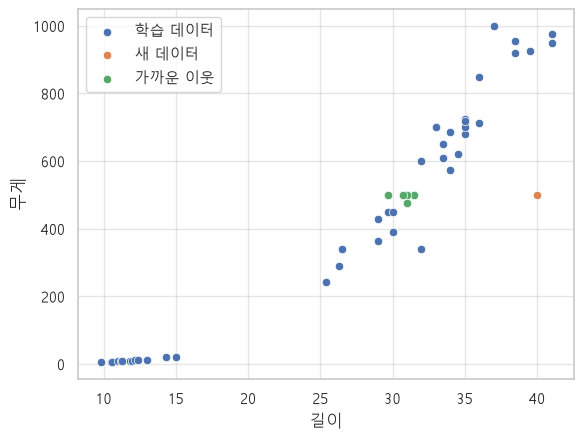

In [52]:
# 최근접 이웃을 시각화 (산점도)
sns.scatterplot(
    x = fish_data[:, 0], # 물고기 길이
    y = fish_data[:, 1], # 물고기 무게
    label = '학습 데이터'
)

# 새 데이터(예측하려는 데이터)를 그래프에 표시
sns.scatterplot(
    x = [40],
    y = [500],
    label = "새 데이터"

)

distances, indices = kn_clf.kneighbors([[40,500]], n_neighbors=5)
# 새 데이터와 가까운 이웃한 데이터의 인덱스를 5개 반환
# print(indices.squeeze()
neighbor_indices = indices.squeeze()

# 가까운 이웃한 데이터를 그래프에 표시
sns.scatterplot(
    x = fish_data[neighbor_indices , 0],
    y = fish_data[neighbor_indices , 1],
    label = '가까운 이웃'
)

plt.xlabel("길이")
plt.ylabel("무게")


plt.show()

## 학습/테스트 세트 분리


## 수상한 도미
도미(길이 25, 무게 150)의 문제


## 표준점수-스케일링
서로 다른 속성의 값의 범위를 맞추기 위한 전처리기법.
모델 성능에 직접적인 영향이 있음.


###  표준점수로 환산하기
표준점수(또는 Z-점수)는 데이터가 평균에서 얼마나 떨어져 있는지를 표준편차 단위로 나타낸 값이다.

$Z = \frac{X - \mu}{\sigma}$

-   $X$는 데이터 값
-   $\mu$는 데이터의 평균
-   $\sigma$는 데이터의 표준편차

특성값에서 평균을 빼고, 표준편차로 나누기.


# 생선 다중분류

| Fish      | Korean Name | Image | Avg Size |
|-----------|-------------|-------|----------|
| Bream     | 도미        | <img src="https://d.pr/i/FaQ4RH+" alt="Bream" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Roach     | 붕어        | <img src="https://d.pr/i/C8jz9h+" alt="Roach" width="300px"> | 평균 길이 20~30cm *(일반적인 붕어 기준)* |
| Whitefish | 흰물고기    | <img src="https://d.pr/i/5z0jBB+" alt="Whitefish" width="300px"> | 평균 길이 30~50cm *(종류에 따라 다름)* |
| Parkki    | 파키        | <img src="https://d.pr/i/CcYfbX+" alt="Parkki" width="300px"> | 평균 길이 15~20cm *(일반적인 파키 기준)* |
| Perch     | 농어        | <img src="https://d.pr/i/JvhJwh+" alt="Perch" width="300px"> | 평균 길이 50~60cm, 최대 1m |
| Pike      | 강꼬치고기  | <img src="https://d.pr/i/NNWlsh+" alt="Pike" width="300px"> | 평균 길이 40~55cm, 최대 1m 이상<br>*(북방강꼬치고기 기준)* |
| Smelt     | 빙어        | <img src="https://d.pr/i/NmXwPX+" alt="Smelt" width="300px"> | 평균 길이 10~15cm *(빙어 기준)* |


**참고 및 설명**
- 도미(Bream)는 대표적으로 참돔을 기준으로 하였으며, 평균 길이 50~60cm, 최대 1m까지 자랍니다.
- 농어(Perch)는 실제로는 Perch(배스)와 농어(Seabass)가 다르나, 표 내 농어는 평균 50~60cm, 최대 1m 이상까지 자랍니다.
- 붕어(Roach), 파키(Parkki), 빙어(Smelt) 등은 한국 내 일반적인 평균 크기를 참고하였습니다.
- 흰물고기(Whitefish), 강꼬치고기(Pike)는 여러 종류가 있으나, 대표적인 종의 평균 크기를 기재했습니다.



## @실습문제: 붓꽃 다중 분류

붓꽃은 세포핵을 둘러싼 꽃받침(sepal)과 꽃잎(petal)으로 구성되어 있으며, 이러한 특징을 기반으로 붓꽃의 품종을 식별할 수 있습니다.

- Setosa (세토사): Setosa는 붓꽃 중에서 가장 작은 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎과 꽃받침이 비교적 짧고 뾰족한 모습을 갖고 있으며, 주로 흰색 또는 연한 분홍색을 띠고 있습니다.

- Versicolor (버시컬러): Versicolor는 Setosa보다 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 보통 연한 보라색이며, 중간 크기의 붓꽃입니다.

- Virginica (버지니카): Virginica는 붓꽃 중에서 가장 크고 긴 꽃잎과 꽃받침을 가지고 있습니다.
꽃잎의 색은 주로 짙은 보라색이며, 다른 품종들에 비해 상대적으로 더 큰 크기를 갖고 있습니다.

![](https://d.pr/i/4egoon+)
